## 1. Load Clean Dataset

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

file_path = "../data/processed/hr_employee_attrition_clean.csv"

df = pd.read_csv(file_path)

df.head()

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [180]:
df.shape

(1470, 32)

In [181]:
df.columns.tolist()

['age',
 'attrition',
 'business_travel',
 'daily_rate',
 'department',
 'distance_from_home',
 'education',
 'education_field',
 'employee_number',
 'environment_satisfaction',
 'gender',
 'hourly_rate',
 'job_involvement',
 'job_level',
 'job_role',
 'job_satisfaction',
 'marital_status',
 'monthly_income',
 'monthly_rate',
 'num_companies_worked',
 'over_time',
 'percent_salary_hike',
 'performance_rating',
 'relationship_satisfaction',
 'stock_option_level',
 'total_working_years',
 'training_times_last_year',
 'work_life_balance',
 'years_at_company',
 'years_in_current_role',
 'years_since_last_promotion',
 'years_with_curr_manager']

## 2. Risk Factor Exploration

Potential attrition risk factors are examined before defining the employee
risk scoring rules.

The selected factors are based on findings from exploratory data analysis,
statistical analysis, and HR business relevance.

Descriptive statistics and category distributions are reviewed to understand
the characteristics of each potential risk factor before translating them
into binary risk indicators.

The thresholds used in the risk segmentation are analytical business rules
defined for this project. They are intended to create a transparent and
interpretable employee risk profile rather than a predictive model.

In [182]:
df["over_time"].value_counts()

over_time
No     1054
Yes     416
Name: count, dtype: int64

In [183]:
df["job_satisfaction"].value_counts().sort_index()

job_satisfaction
1    289
2    280
3    442
4    459
Name: count, dtype: int64

In [184]:
df["environment_satisfaction"].value_counts().sort_index()

environment_satisfaction
1    284
2    287
3    453
4    446
Name: count, dtype: int64

In [185]:
df["job_involvement"].value_counts().sort_index()

job_involvement
1     83
2    375
3    868
4    144
Name: count, dtype: int64

In [186]:
df["monthly_income"].describe().round(2)

count     1470.00
mean      6502.93
std       4707.96
min       1009.00
25%       2911.00
50%       4919.00
75%       8379.00
max      19999.00
Name: monthly_income, dtype: float64

In [187]:
df["years_at_company"].describe().round(2)

count    1470.00
mean        7.01
std         6.13
min         0.00
25%         3.00
50%         5.00
75%         9.00
max        40.00
Name: years_at_company, dtype: float64

In [188]:
df["job_level"].value_counts().sort_index()

job_level
1    543
2    534
3    218
4    106
5     69
Name: count, dtype: int64

## 3. Risk Factor Definition & Analysis

This section evaluates potential employee attrition risk factors identified
from the exploratory data analysis and statistical analysis.

Seven factors are selected for the rule-based risk segmentation:

* Overtime
* Low Job Satisfaction
* Low Environment Satisfaction
* Low Job Involvement
* Low Job Level
* Early Tenure
* Low Income

Each factor is converted into a binary indicator:

* `1` = the employee meets the defined risk criterion
* `0` = the employee does not meet the risk criterion

The thresholds are predefined analytical rules designed to create a
transparent and interpretable risk profile. They should not be interpreted
as statistically optimized thresholds or causal determinants of attrition.

The attrition rate and employee count are then calculated for each risk
factor to understand how these characteristics relate to observed employee
attrition in the dataset.

In [189]:
risk_factors = {
    "Overtime": df["over_time"] == "Yes",
    "Low Job Satisfaction": df["job_satisfaction"] <= 2,
    "Low Environment Satisfaction": df["environment_satisfaction"] <= 2,
    "Low Job Involvement": df["job_involvement"] <= 2,
    "Low Job Level": df["job_level"] == 1,
    "Early Tenure": df["years_at_company"] <= 3,
    "Low Income": df["monthly_income"] <= df["monthly_income"].median()
}

risk_factor_results = []

for factor, condition in risk_factors.items():
    attrition_rate = (
        df.loc[condition, "attrition"]
          .eq("Yes")
          .mean() * 100
    )

    employee_count =  condition.sum()

    risk_factor_results.append({
        "risk_factor": factor,
        "employee_count": employee_count,
        "attrition_rate": attrition_rate
    })

risk_factor_results = (
    pd.DataFrame(risk_factor_results)
    .sort_values("attrition_rate", ascending=False)
    .round(2)
)

risk_factor_results

,risk_factor,employee_count,attrition_rate
0,Overtime,416,30.53
4,Low Job Level,543,26.34
5,Early Tenure,470,25.96
6,Low Income,735,21.77
3,Low Job Involvement,458,21.62
2,Low Environment Satisfaction,571,20.14
1,Low Job Satisfaction,569,19.68


In [190]:
df["risk_overtime"] = (df["over_time"] == "Yes").astype(int)

df["risk_low_job_satisfaction"] = (
    df["job_satisfaction"] <= 2
).astype(int)

df["risk_low_environment_satisfaction"] = (
    df["environment_satisfaction"] <= 2
).astype(int)

df["risk_low_job_involvement"] = (
    df["job_involvement"] <= 2
).astype(int)

df["risk_low_job_level"] = (
    df["job_level"] == 1
).astype(int)

df["risk_early_tenure"] = (
    df["years_at_company"] <= 3
).astype(int)

df["risk_low_income"] = (
    df["monthly_income"] <= df["monthly_income"].median()
).astype(int)

### Risk Indicator Construction

The selected risk factors are converted into binary indicators so that each
employee can be evaluated consistently across the defined risk criteria.

Each employee receives one risk point for every criterion they meet.

In [191]:
risk_factor_columns = [
    "risk_overtime",
    "risk_low_job_satisfaction",
    "risk_low_environment_satisfaction",
    "risk_low_job_involvement",
    "risk_low_job_level",
    "risk_early_tenure",
    "risk_low_income"
]

df[risk_factor_columns].sum().sort_values(ascending=False)

risk_low_income                      735
risk_low_environment_satisfaction    571
risk_low_job_satisfaction            569
risk_low_job_level                   543
risk_early_tenure                    470
risk_low_job_involvement             458
risk_overtime                        416
dtype: int64

## 4. Risk Scoring & Segmentation

A rule-based risk score is calculated by summing the binary risk indicators
for each employee.

Because seven risk factors are included, the resulting risk score ranges
from 0 to 7.

A higher score indicates that an employee meets a greater number of predefined
risk criteria.

The score represents the accumulation of risk indicators and should not be
interpreted as a probability of attrition.

In [192]:
df["risk_score"] = df[risk_factor_columns].sum(axis=1)

risk_score_distribution = (
    df["risk_score"]
      .value_counts()
      .sort_index()
)

risk_score_distribution

risk_score
0    100
1    288
2    375
3    301
4    255
5    113
6     30
7      8
Name: count, dtype: int64

In [193]:
risk_score_attrition = (
    df.groupby("risk_score")["attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .round(2)
)

risk_score_attrition

risk_score
0     3.00
1     6.60
2    10.40
3    11.63
4    25.10
5    42.48
6    76.67
7    75.00
Name: attrition, dtype: float64

In [194]:
risk_score_summary = pd.DataFrame({
    "employee_count": risk_score_distribution,
    "attrition_rate": risk_score_attrition
})

risk_score_summary

,employee_count,attrition_rate
risk_score,,
0,100,3.00
1,288,6.60
2,375,10.40
3,301,11.63
4,255,25.10
5,113,42.48
6,30,76.67
7,8,75.00


### Risk Segment Definition

Employees are grouped into three analytical risk segments based on their
total risk score:

| Risk Segment | Risk Score | Interpretation                                  |
| ------------ | ---------: | ----------------------------------------------- |
| Low Risk     |        0–3 | Limited number of predefined risk indicators    |
| Medium Risk  |          4 | Moderate accumulation of risk indicators        |
| High Risk    |        5–7 | High accumulation of predefined risk indicators |

These thresholds are rule-based analytical classifications created to
support employee profiling and retention prioritization.

They are not predictive model thresholds and do not represent individual
probabilities of attrition.

In [195]:
def assign_risk_segment(score):
    if score <= 3:
        return "Low Risk"
    elif score == 4:
        return "Medium Risk"
    else:
        return "High Risk"

df["risk_segment"] = df["risk_score"].apply(assign_risk_segment)

In [196]:
risk_segment_summary = (
    df.groupby("risk_segment", observed=True)
      .agg(
          employee_count=("employee_number", "count"),
          attrition_rate=("attrition", lambda x: (x == "Yes").mean() * 100)
      )
      .round(2)
)

risk_segment_summary

,employee_count,attrition_rate
risk_segment,,
High Risk,151,50.99
Low Risk,1064,9.02
Medium Risk,255,25.10


### Business Interpretation

The rule-based risk segmentation shows a clear relationship between
the number of identified risk factors and observed employee attrition.

Employees classified as Low Risk recorded an observed attrition rate of
9.02%, compared with 25.10% among Medium Risk employees and 50.99% among
High Risk employees.

The High Risk segment therefore shows substantially higher observed
attrition than the Low Risk segment, indicating that the combination of
multiple risk factors can be useful for prioritizing employee retention
analysis.

This segmentation is an analytical risk profile rather than a predictive
model. The observed attrition rates describe historical patterns in the
dataset and should not be interpreted as individual employee probabilities
of leaving.

## 5. Risk Segment Profile

This section examines the prevalence of each predefined risk factor within
the Low Risk, Medium Risk, and High Risk segments.

The analysis helps identify the characteristics that most commonly appear
within each risk segment and provides a more detailed profile of the
employees classified as High Risk.

In [197]:
risk_factor_profile = (
    df.groupby("risk_segment", observed=True)[risk_factor_columns]
      .mean()
      .mul(100)
      .round(2)
)

risk_factor_profile

,risk_overtime,risk_low_job_satisfaction,risk_low_environment_satisfaction,risk_low_job_involvement,risk_low_job_level,risk_early_tenure,risk_low_income
risk_segment,,,,,,,
High Risk,58.94,68.87,62.91,65.56,94.70,80.79,98.68
Low Risk,22.65,32.33,32.24,24.91,18.70,18.05,33.55
Medium Risk,33.73,47.45,52.16,36.86,78.82,61.18,89.80


### Business Interpretation

The risk factor profile shows that High Risk employees are primarily
characterized by lower income and lower job level, with 98.68% and 94.70%
of High Risk employees meeting these respective risk criteria.

Early tenure is also prominent, with 80.79% of High Risk employees classified
as having early tenure. In addition, low job satisfaction, low environment
satisfaction, and low job involvement are present in more than 60% of the
High Risk segment.

Overtime is also relatively common among High Risk employees, affecting
58.94% of the segment.

These findings suggest that the High Risk segment is largely associated with
a combination of compensation, career level, early tenure, workload, and
employee experience factors.

However, these risk factors are rule-based analytical indicators and should
not be interpreted as causal drivers of employee attrition.

In [198]:
risk_factor_profile_plot = risk_factor_profile.T

risk_factor_profile_plot

risk_segment,High Risk,Low Risk,Medium Risk
risk_overtime,58.94,22.65,33.73
risk_low_job_satisfaction,68.87,32.33,47.45
risk_low_environment_satisfaction,62.91,32.24,52.16
risk_low_job_involvement,65.56,24.91,36.86
risk_low_job_level,94.70,18.70,78.82
risk_early_tenure,80.79,18.05,61.18
risk_low_income,98.68,33.55,89.80


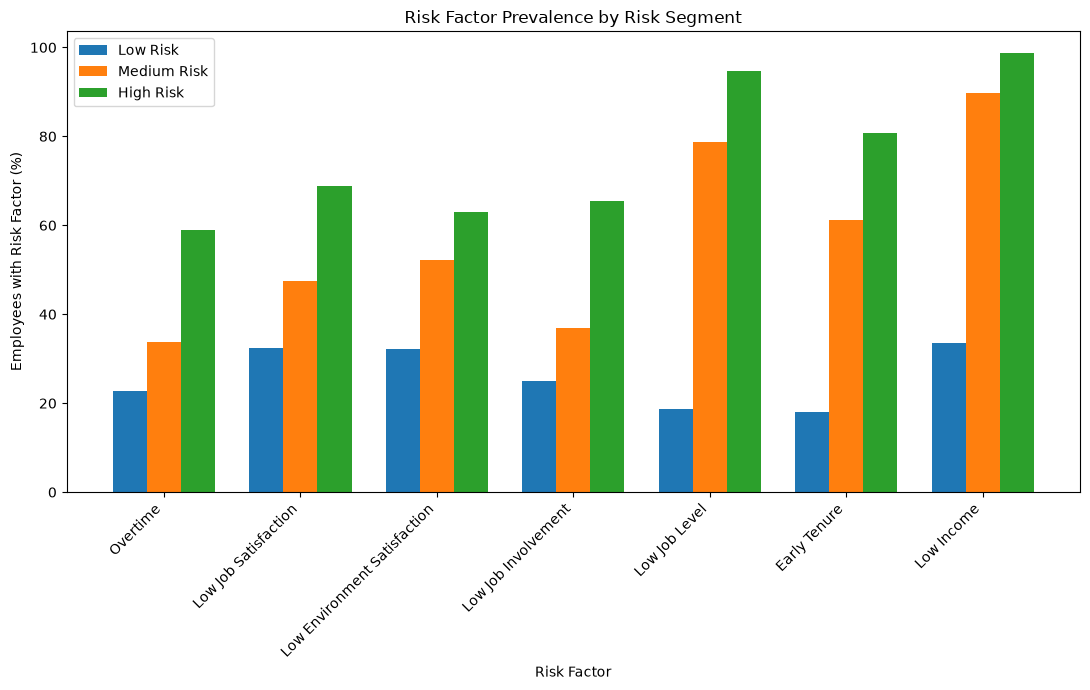

In [199]:
plt.figure(figsize=(11, 7))

x = np.arange(len(risk_factor_profile_plot.index))
width = 0.25

plt.bar(
    x - width,
    risk_factor_profile_plot["Low Risk"],
    width,
    label="Low Risk"
)

plt.bar(
    x,
    risk_factor_profile_plot["Medium Risk"],
    width,
    label="Medium Risk"
)
plt.bar(
    x + width,
    risk_factor_profile_plot["High Risk"],
    width,
    label="High Risk"
)

plt.xticks(
    x,
    [
        "Overtime",
        "Low Job Satisfaction",
        "Low Environment Satisfaction",
        "Low Job Involvement",
        "Low Job Level",
        "Early Tenure",
        "Low Income"
    ],
    rotation=45,
    ha="right"
)

plt.xlabel("Risk Factor")
plt.ylabel("Employees with Risk Factor (%)")
plt.title("Risk Factor Prevalence by Risk Segment")

plt.legend()

plt.tight_layout()
plt.show()

### Risk Segment Interpretation

The risk factor prevalence shows a clear separation between the three
employee risk segments.

High Risk employees have substantially higher exposure to most defined risk
factors, particularly low income (98.68%), low job level (94.70%), and early
tenure (80.79%). Low job satisfaction, low job involvement, low environment
satisfaction, and overtime are also relatively common within the High Risk
segment.

The prevalence of most risk factors generally increases from Low Risk to
High Risk, supporting the usefulness of the rule-based risk segmentation as
an analytical profiling framework.

However, the segmentation represents employee characteristics based on
predefined business rules and should not be interpreted as a predictive
model or as evidence of causal relationships.

## 6. High-Risk Workforce Distribution

This section examines where High Risk employees are concentrated across
departments and job roles.

Both employee counts and High-Risk Rates are evaluated.

Employee counts indicate the overall number of High Risk employees within a
group, while High-Risk Rate measures the proportion of employees in that
group classified as High Risk.

Using both measures helps avoid overinterpreting groups that have a high rate
but a relatively small employee population.

In [200]:
high_risk_department = (
    df[df["risk_segment"] == "High Risk"]
    .groupby("department")
    .size()
    .sort_values(ascending=False)
)

high_risk_department

department
Research & Development    117
Sales                      28
Human Resources             6
dtype: int64

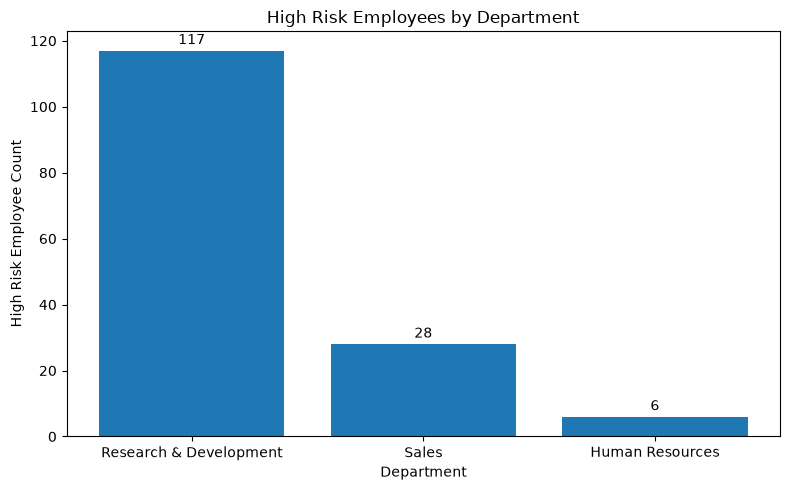

In [201]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    high_risk_department.index,
    high_risk_department.values
)

plt.title("High Risk Employees by Department")
plt.xlabel("Department")
plt.ylabel("High Risk Employee Count")

for bar, value in zip(bars, high_risk_department.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{value:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [202]:
department_risk_profile = (
    df.groupby("department")
      .agg(
          total_employees=("employee_number", "count"),
          high_risk_employees=("risk_segment", lambda x: (x == "High Risk").sum())
      )
)

department_risk_profile["high_risk_rate"] = (
    department_risk_profile["high_risk_employees"]
    / department_risk_profile["total_employees"]
    * 100
)

department_risk_profile = (
    department_risk_profile
    .sort_values("high_risk_rate", ascending=False)
    .round(2)
)

department_risk_profile

,total_employees,high_risk_employees,high_risk_rate
department,,,
Research & Development,961,117,12.17
Human Resources,63,6,9.52
Sales,446,28,6.28


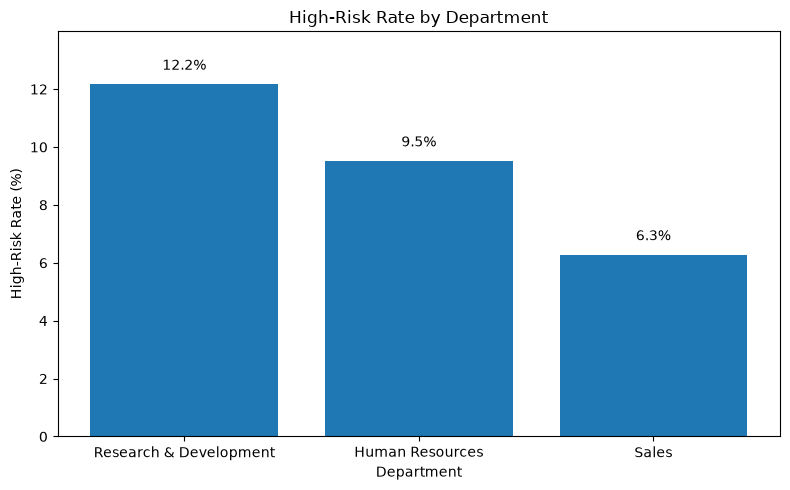

In [203]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    department_risk_profile.index,
    department_risk_profile["high_risk_rate"]
)

plt.title("High-Risk Rate by Department")
plt.xlabel("Department")
plt.ylabel("High-Risk Rate (%)")

for bar, value in zip(
    bars,
    department_risk_profile["high_risk_rate"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(
    0,
    department_risk_profile["high_risk_rate"].max() * 1.15
)

plt.tight_layout()
plt.show()

In [204]:
high_risk_job_role = (
    df[df["risk_segment"] == "High Risk"]
    .groupby("job_role")
    .size()
    .sort_values(ascending=False)
)

high_risk_job_role

job_role
Laboratory Technician        57
Research Scientist           57
Sales Representative         24
Human Resources               6
Sales Executive               4
Manufacturing Director        2
Healthcare Representative     1
dtype: int64

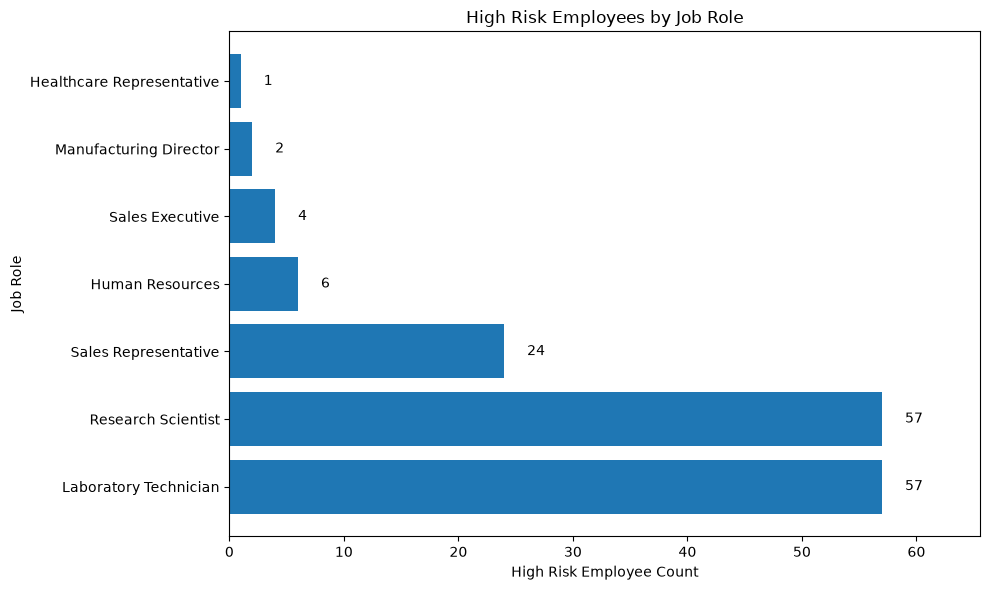

In [205]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    high_risk_job_role.index,
    high_risk_job_role.values
)

plt.title("High Risk Employees by Job Role")
plt.xlabel("High Risk Employee Count")
plt.ylabel("Job Role")

for bar, value in zip(bars, high_risk_job_role.values):
    plt.text(
        bar.get_width() + 2,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center"
    )

plt.xlim(0, max(high_risk_job_role.values) * 1.15)

plt.tight_layout()
plt.show()

In [206]:
job_role_risk_profile = (
    df.groupby("job_role")
      .agg(
          total_employees=("employee_number", "count"),
          high_risk_employees=("risk_segment", lambda x: (x == "High Risk").sum())
      )
)

job_role_risk_profile["high_risk_rate"] = (
    job_role_risk_profile["high_risk_employees"]
    / job_role_risk_profile["total_employees"]
    * 100
)

job_role_risk_profile = (
    job_role_risk_profile
    .sort_values("high_risk_rate", ascending=False)
    .round(2)
)

job_role_risk_profile

,total_employees,high_risk_employees,high_risk_rate
job_role,,,
Sales Representative,83,24,28.92
Laboratory Technician,259,57,22.01
Research Scientist,292,57,19.52
Human Resources,52,6,11.54
Manufacturing Director,145,2,1.38
Sales Executive,326,4,1.23
Healthcare Representative,131,1,0.76
Manager,102,0,0.00
Research Director,80,0,0.00


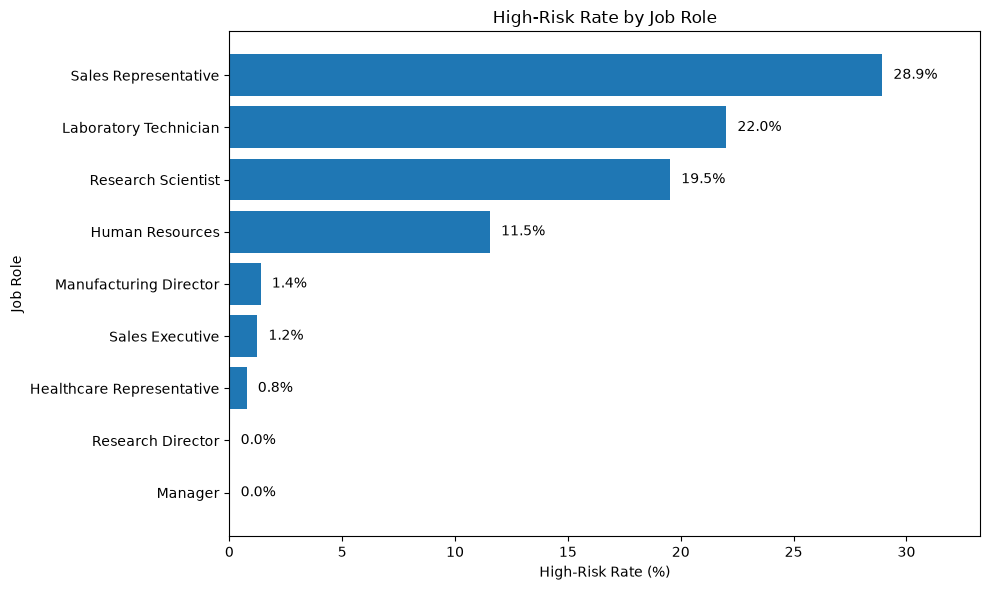

In [207]:
job_role_risk_plot = job_role_risk_profile.sort_values(
    "high_risk_rate",
    ascending=True
)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    job_role_risk_plot.index,
    job_role_risk_plot["high_risk_rate"]
)

plt.title("High-Risk Rate by Job Role")
plt.xlabel("High-Risk Rate (%)")
plt.ylabel("Job Role")

for bar, value in zip(
    bars,
    job_role_risk_plot["high_risk_rate"]
):
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.xlim(
    0,
    job_role_risk_plot["high_risk_rate"].max() * 1.15
)

plt.tight_layout()
plt.show()

### Business Interpretation — High-Risk Employee Profile

The rule-based risk segmentation identifies 151 employees as High Risk, representing approximately 10.0% of the workforce. Despite being a relatively small segment, High Risk employees have an attrition rate of 50.99%, substantially higher than the Medium Risk segment at 25.10% and the Low Risk segment at 9.02%.

The risk factor profile shows that Low Income and Low Job Level are the most prevalent characteristics among High Risk employees, affecting 98.68% and 94.70% of the segment, respectively. Early Tenure is also prevalent, with 80.79% of High Risk employees having relatively short company tenure. In addition, Low Job Satisfaction, Low Job Involvement, and Low Environment Satisfaction are present in 68.87%, 65.56%, and 62.91% of High Risk employees. Overtime is present in 58.94% of the High Risk segment.

These patterns indicate that High Risk employees are commonly characterized by a combination of lower compensation and job level, shorter tenure, and less favorable workplace experiences. The combination of these factors provides a useful profile for identifying employee groups that may require greater retention attention.

At the department level, Research & Development has the largest number of High Risk employees with 117 employees. When considering the proportion of employees within each department, Research & Development also has the highest High-Risk Rate at 12.17%, followed by Human Resources at 9.52% and Sales at 6.28%.

At the job-role level, Sales Representatives have the highest High-Risk Rate at 28.92%, followed by Laboratory Technicians at 22.01% and Research Scientists at 19.52%. These job roles may therefore warrant closer examination when developing targeted retention initiatives.

Overall, the risk segmentation provides a practical framework for prioritizing employee groups based on the presence of multiple attrition-related risk factors. However, the segmentation is rule-based and should be interpreted as an analytical risk profile rather than a predictive model or evidence of causal relationships. Further statistical analysis is required to determine whether specific categorical factors have statistically significant associations with employee attrition.